# Getting Started with `bw_timex`: explicit processes and products

This notebook is a **fleet-flavored**, product-explicit getting-started
example. It models a small program that installs **100 residential heat pumps**
between 2025 and 2045, and uses `bw_timex` to compute the program's
time-explicit greenhouse-gas footprint.

**Research question.** A municipality plans to subsidize the installation
of 100 residential air-source heat pumps between 2025 and 2045 to replace
gas boilers. What is the cumulative GHG footprint of that program when we
account for

1. the **electricity grid decarbonizing** between 2025 and 2035, and
2. heat pump models installed in **2035 having ~30 % better COP** than
   those installed in 2025?

Brightway supports both the **chimaera** style (one node bundles process
and reference product) and the **explicit product/process** style we use
here (see [the Brightway inventory docs](https://docs.brightway.dev/en/latest/content/overview/inventory.html#processes-products-and-something-in-between)).
For fleet/stock work the explicit style is convenient because the
**production edge** between the lifecycle process and the unit-good product
is exactly where the install-year distribution naturally lives.

## The system

```mermaid
flowchart LR
subgraph background[<i>background</i>]
    E25(["electricity_market_2025"]):::bg
    E35(["electricity_market_2035"]):::bg
end

subgraph foreground[<i>foreground</i>]
    HPP([heat_pump]):::product
    HPL("heat_pump_lifecycle"):::fg
end

subgraph biosphere[<i>biosphere</i>]
    CO2("CO2"):::bio
    R("refrigerant_leak"):::bio
end

HPL-->|"1 unit"|HPP
E25-->|"18 000 kWh"|HPL
E35-->|"18 000 kWh"|HPL
HPL-.->|"2 kg"|R

classDef fg color:#222832, fill:#3fb1c5, stroke:none;
classDef product color:#222832, fill:#9c5ffd, stroke:none;
classDef bg color:#222832, fill:#3fb1c5, stroke:none;
classDef bio color:#222832, fill:#9c5ffd, stroke:none;
style background fill:none, stroke:none;
style foreground fill:none, stroke:none;
style biosphere fill:none, stroke:none;
```

- `heat_pump` is the **unit good** the municipality demands. The product
  node is bare metadata: name, unit, no exchanges.
- `heat_pump_lifecycle` is the **per-unit lifecycle process** for one heat
  pump: it owns the materials, the install, the operating electricity over
  ~18 years, the refrigerant leak, and end-of-life. All exchange amounts
  are per `1 heat_pump`.

Demanding `heat_pump = 100` therefore says "100 heat pumps go through
their full lifecycle." Output-side and input-side relative temporal
distributions (RTDs) decide *when in calendar time* each unit's install
and operating electricity actually happen.

## Why this needs explicit product/process

A heat pump's **install year** and the **calendar years it draws
electricity** are different timestamps:

- install year: when the unit is built, deployed, refrigerant-charged.
- operating years: ~18 years of electricity use *after* install.

With **chimaera** nodes the process *is* the product, so there is no
production edge to host an install-year RTD — install timing and
operating timing collapse onto one node.

With **explicit product/process** the production edge `heat_pump_lifecycle
→ heat_pump` is a natural home for the install-year RTD (`date_consumer`
in the timeline = install vintage), while the electricity edge carries an
input-side RTD describing the per-unit lifetime kWh profile (`date_producer`
= calendar year of draw). Vintage-locked efficiency improvements (newer
install years use less kWh per unit-life) sit on the electricity edge with
`temporal_evolution_reference="consumer"`.

## Project setup and background databases

Two electricity markets — one for 2025 (high CO2 intensity) and one for
2035 (decarbonized) — plus a tiny biosphere with `CO2` and a generic
`refrigerant_leak` (we keep it in the inventory but do not characterize it
in the static method, just like `CO2` in the upstream getting-started
notebook).

In [1]:
from datetime import datetime

import bw2data as bd
import numpy as np
from bw_temporalis import TemporalDistribution

bd.projects.set_current("getting_started_explicit_process_product_heatpump")

for db in list(bd.databases):
    del bd.databases[db]
for method in list(bd.methods):
    del bd.methods[method]

bd.Database("biosphere").write(
    {
        ("biosphere", "CO2"): {
            "type": "emission",
            "name": "CO2",
            "unit": "kg",
        },
        ("biosphere", "refrigerant_leak"): {
            "type": "emission",
            "name": "refrigerant leak",
            "unit": "kg",
        },
    }
)

for db_name, co2_per_kwh in [
    ("electricity_market_2025", 0.40),
    ("electricity_market_2035", 0.10),
]:
    bd.Database(db_name).write(
        {
            (db_name, "elec"): {
                "name": "electricity market",
                "reference product": "electricity",
                "location": "DE",
                "unit": "kWh",
                "exchanges": [
                    {
                        "amount": 1,
                        "type": "production",
                        "input": (db_name, "elec"),
                    },
                    {
                        "amount": co2_per_kwh,
                        "type": "biosphere",
                        "input": ("biosphere", "CO2"),
                    },
                ],
            },
        }
    )

bd.Method(("our", "method")).write([(("biosphere", "CO2"), 1)])

/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.11/site-packages/bw2calc/__init__.py:54: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 19021.79it/s]

00:23:22+0200 [info     ] Vacuuming database            


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 25731.93it/s]

00:23:22+0200 [info     ] Vacuuming database            


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 14979.66it/s]

00:23:22+0200 [info     ] Vacuuming database            


## Part 1 — Hand-picked relative temporal distributions

We start with three small, made-up RTDs so the mechanics are clear before
Part 2 derives them from a real dMFA.

- `td_install` lives on the production edge `heat_pump_lifecycle →
  heat_pump`. It is the **install-year distribution** of the fleet,
  normalized to one unit. Output-side RTD.
- `td_use` lives on the electricity input. It is the **per-unit lifetime
  electricity profile**, relative to a unit's install year. Input-side
  RTD.
- `cop_factors` are vintage-locked efficiency multipliers on the
  electricity edge with `temporal_evolution_reference="consumer"`: a
  2035-vintage HP keeps its better COP across all its operating years.

In [2]:
td_install = TemporalDistribution(
    date=np.array([0, 5, 10], dtype="timedelta64[Y]"),
    amount=np.array([0.2, 0.5, 0.3]),
)

td_use = TemporalDistribution(
    date=np.array([0, 6, 12], dtype="timedelta64[Y]"),
    amount=np.array([0.4, 0.4, 0.2]),
)

cop_factors = {
    datetime(2025, 1, 1): 1.0,
    datetime(2035, 1, 1): 0.7,   # 2035-vintage HPs use 30% less electricity
}

### Reading the RTDs at unit and fleet scale

RTDs are always **per unit of the edge flow** (weights sum to 1). The
fleet picture comes from multiplying by the demand quantity — three
linearities stacked:

1. The LCA matrix solve is linear in demand.
2. RTD application is linear in process scaling: a vintage with N runs
   contributes N times the per-unit RTD shape.
3. Background relinking and `temporal_evolution_factors` are linear
   scalings on individual rows.

So `td_install = [0yr: 0.2, 5yr: 0.5, 10yr: 0.3]` and `demand=100` means:
20 units installed in 2025, 50 in 2030, 30 in 2035. And `td_use = [0yr:
0.4, 6yr: 0.4, 12yr: 0.2]` means each installed unit draws 40 % / 40 %
/ 20 % of its 18 000 kWh at install year, +6 yr, +12 yr. The fleet
year-by-year electricity demand is just these two shapes combined per
vintage.

## The foreground: one product, one process

Product node is bare. Process node carries all exchanges, including one
production edge whose target is the product.

In [3]:
bd.Database("foreground").write(
    {
        ("foreground", "heat_pump"): {
            "name": "heat_pump",
            "type": bd.labels.product_node_default,
            "unit": "unit",
            "location": "DE",
            "exchanges": [],
        },
        ("foreground", "heat_pump_lifecycle"): {
            "name": "heat_pump_lifecycle",
            "type": bd.labels.process_node_default,
            "unit": "unit",
            "location": "DE",
            "exchanges": [
                {
                    "amount": 1,
                    "type": bd.labels.production_edge_default,
                    "input": ("foreground", "heat_pump"),
                    "temporal_distribution": td_install,
                },
                {
                    "amount": 18_000,
                    "type": bd.labels.consumption_edge_default,
                    "input": ("electricity_market_2025", "elec"),
                    "temporal_distribution": td_use,
                    "temporal_evolution_factors": cop_factors,
                    "temporal_evolution_reference": "consumer",
                },
                {
                    "amount": 2,
                    "type": "biosphere",
                    "input": ("biosphere", "refrigerant_leak"),
                    "temporal_distribution": td_install,
                },
            ],
        },
    }
)

for db in bd.databases:
    bd.Database(db).process()

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 18517.90it/s]

00:23:23+0200 [info     ] Vacuuming database            


## Tell `bw_timex` which databases represent which years

In [4]:
database_dates = {
    "electricity_market_2025": datetime.strptime("2025", "%Y"),
    "electricity_market_2035": datetime.strptime("2035", "%Y"),
    "foreground": "dynamic",
}

## Build the timeline

The functional unit demands the **product** (`heat_pump`). The total
demand of 100 units is the cumulative fleet over the horizon; the
install-year RTD distributes those installs across calendar years.

In [5]:
from bw_timex import TimexLCA

heat_pump = bd.get_node(database="foreground", code="heat_pump")

tlca = TimexLCA(
    demand={heat_pump: 100},
    method=("our", "method"),
    database_dates=database_dates,
)

tlca.build_timeline(
    starting_datetime=datetime(2025, 1, 1),
    temporal_grouping="year",
)

2026-05-09 00:23:23.309 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-09 00:23:23.309 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-09 00:23:23.316 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-09 00:23:23.318 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-09 00:23:23.319 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-09 00:23:23.334 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2041-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-09 00:23:23.334 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2042-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-09 00:23:23.334 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2047-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


Starting graph traversal
Calculation count: 1


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2025-01-01,electricity market,2025-01-01,heat_pump_lifecycle,7200.0,{'electricity_market_2025': 1}
1,2025-01-01,heat_pump_lifecycle,2025-01-01,-1,20.0,None
2,2030-01-01,electricity market,2030-01-01,heat_pump_lifecycle,7200.0,"{'electricity_market_2025': 0.5, 'electricity_..."
3,2030-01-01,heat_pump_lifecycle,2030-01-01,-1,50.0,None
4,2031-01-01,electricity market,2025-01-01,heat_pump_lifecycle,7200.0,"{'electricity_market_2025': 0.4, 'electricity_..."
5,2035-01-01,electricity market,2035-01-01,heat_pump_lifecycle,7200.0,{'electricity_market_2035': 1}
6,2035-01-01,heat_pump_lifecycle,2035-01-01,-1,30.0,None
7,2036-01-01,electricity market,2030-01-01,heat_pump_lifecycle,7200.0,{'electricity_market_2035': 1}
8,2037-01-01,electricity market,2025-01-01,heat_pump_lifecycle,3600.0,{'electricity_market_2035': 1}
9,2041-01-01,electricity market,2035-01-01,heat_pump_lifecycle,7200.0,{'electricity_market_2035': 1}


Each electricity row carries two dates:

- `date_consumer`: the install vintage of the heat-pump cohort consuming
  that electricity. Used for vintage-locked COP factors.
- `date_producer`: the calendar year the electricity is actually drawn.
  Used for relinking to the time-stamped background databases.

In [6]:
tlca.timeline[
    [
        "producer_name",
        "consumer_name",
        "date_producer",
        "date_consumer",
        "amount",
        "temporal_market_shares",
    ]
].sort_values(["date_consumer", "date_producer", "producer_name"])

,producer_name,consumer_name,date_producer,date_consumer,amount,temporal_market_shares
0,electricity market,heat_pump_lifecycle,2025-01-01,2025-01-01,7200.0,{'electricity_market_2025': 1}
1,heat_pump_lifecycle,-1,2025-01-01,2025-01-01,20.0,None
4,electricity market,heat_pump_lifecycle,2031-01-01,2025-01-01,7200.0,"{'electricity_market_2025': 0.4, 'electricity_..."
8,electricity market,heat_pump_lifecycle,2037-01-01,2025-01-01,3600.0,{'electricity_market_2035': 1}
2,electricity market,heat_pump_lifecycle,2030-01-01,2030-01-01,7200.0,"{'electricity_market_2025': 0.5, 'electricity_..."
3,heat_pump_lifecycle,-1,2030-01-01,2030-01-01,50.0,None
7,electricity market,heat_pump_lifecycle,2036-01-01,2030-01-01,7200.0,{'electricity_market_2035': 1}
10,electricity market,heat_pump_lifecycle,2042-01-01,2030-01-01,3600.0,{'electricity_market_2035': 1}
5,electricity market,heat_pump_lifecycle,2035-01-01,2035-01-01,7200.0,{'electricity_market_2035': 1}
6,heat_pump_lifecycle,-1,2035-01-01,2035-01-01,30.0,None


### Per-vintage breakdown: how unit process + RTDs aggregate to fleet

In [7]:
from bw_timex.utils import get_temporal_evolution_factor

elec_rows = tlca.timeline[
    tlca.timeline["producer_name"].str.contains("electricity")
].copy()
elec_rows["install_year"] = elec_rows["date_consumer"].dt.year
elec_rows["draw_year"] = elec_rows["date_producer"].dt.year
elec_rows["cop_factor"] = elec_rows["date_consumer"].apply(
    lambda d: get_temporal_evolution_factor(cop_factors, d)
)
elec_rows["effective_kWh"] = elec_rows["amount"].astype(float) * elec_rows["cop_factor"]

elec_rows[
    [
        "install_year",
        "draw_year",
        "amount",
        "cop_factor",
        "effective_kWh",
        "temporal_market_shares",
    ]
].sort_values(["install_year", "draw_year"])

,install_year,draw_year,amount,cop_factor,effective_kWh,temporal_market_shares
0,2025,2025,7200.0,1.00,7200.0,{'electricity_market_2025': 1}
4,2025,2031,7200.0,1.00,7200.0,"{'electricity_market_2025': 0.4, 'electricity_..."
8,2025,2037,3600.0,1.00,3600.0,{'electricity_market_2035': 1}
2,2030,2030,7200.0,0.85,6120.0,"{'electricity_market_2025': 0.5, 'electricity_..."
7,2030,2036,7200.0,0.85,6120.0,{'electricity_market_2035': 1}
10,2030,2042,3600.0,0.85,3060.0,{'electricity_market_2035': 1}
5,2035,2035,7200.0,0.70,5040.0,{'electricity_market_2035': 1}
9,2035,2041,7200.0,0.70,5040.0,{'electricity_market_2035': 1}
11,2035,2047,3600.0,0.70,2520.0,{'electricity_market_2035': 1}


Aggregating by install vintage shows the COP improvement clearly:

In [8]:
elec_rows.groupby("install_year", as_index=False).agg(
    raw_kWh=("amount", "sum"),
    cop_factor=("cop_factor", "first"),
    effective_kWh=("effective_kWh", "sum"),
)

,install_year,raw_kWh,cop_factor,effective_kWh
0,2025,18000.0,1.00,18000.0
1,2030,18000.0,0.85,15300.0
2,2035,18000.0,0.70,12600.0


## Calculate the LCI and the static LCIA score

In [9]:
tlca.lci()
tlca.static_lcia()

tlca.static_score

2026-05-09 00:23:23.369 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-09 00:23:23.376 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


256680.00382483003

### Compare against the static base LCA

The static base LCA is the fleet's footprint *without* time-explicit
relinking and *without* the vintage-locked COP improvements. It uses
whatever background was originally chosen on the foreground exchange
(`electricity_market_2025`).

In [10]:
print(f"Static base LCA score:        {tlca.base_lca.score:>14,.2f} kg CO2-eq")
print(f"Time-explicit static score:   {tlca.static_score:>14,.2f} kg CO2-eq")
print(
    "Reduction from time-explicit modelling: "
    f"{tlca.base_lca.score - tlca.static_score:>14,.2f} kg CO2-eq "
    f"({100 * (tlca.base_lca.score - tlca.static_score) / tlca.base_lca.score:.1f} %)"
)

Static base LCA score:            720,000.01 kg CO2-eq
Time-explicit static score:       256,680.00 kg CO2-eq
Reduction from time-explicit modelling:     463,320.01 kg CO2-eq (64.3 %)


The time-explicit score is lower for two reasons: some operating
electricity is sourced from the cleaner 2035 grid mix, and 2035-vintage
heat pumps draw 30 % less electricity than 2025-vintage ones. The next
cell isolates the second effect.

### Isolating the vintage-locked COP improvement

We temporarily remove the `temporal_evolution_factors` from the
electricity edge and rerun the same time-explicit model. The only
difference is the vintage-locked COP improvements; everything else
(install RTD, use RTD, background relinking) stays.

In [11]:
hp_lifecycle = bd.get_node(database="foreground", code="heat_pump_lifecycle")
elec_edge = next(
    e for e in hp_lifecycle.technosphere() if e.input["name"] == "electricity market"
)

saved_factors = elec_edge["temporal_evolution_factors"]
saved_reference = elec_edge["temporal_evolution_reference"]
del elec_edge["temporal_evolution_factors"]
del elec_edge["temporal_evolution_reference"]
elec_edge.save()
bd.Database("foreground").process()

tlca_no_evolution = TimexLCA(
    demand={heat_pump: 100},
    method=("our", "method"),
    database_dates=database_dates,
)
tlca_no_evolution.build_timeline(
    starting_datetime=datetime(2025, 1, 1),
    temporal_grouping="year",
)
tlca_no_evolution.lci()
tlca_no_evolution.static_lcia()

elec_edge["temporal_evolution_factors"] = saved_factors
elec_edge["temporal_evolution_reference"] = saved_reference
elec_edge.save()
bd.Database("foreground").process()

print(
    f"Without COP improvement: {tlca_no_evolution.static_score:>14,.2f} kg CO2-eq"
)
print(
    f"With COP improvement:    {tlca.static_score:>14,.2f} kg CO2-eq"
)
print(
    f"COP-attributable saving: {tlca_no_evolution.static_score - tlca.static_score:>14,.2f} kg CO2-eq"
)

2026-05-09 00:23:23.406 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-09 00:23:23.406 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-09 00:23:23.412 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-09 00:23:23.414 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-09 00:23:23.414 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-09 00:23:23.425 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2042-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-09 00:23:23.425 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2047-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-09 00:23:23.433 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-09 00:23:23.439 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


Starting graph traversal
Calculation count: 1
Without COP improvement:     294,480.00 kg CO2-eq
With COP improvement:        256,680.00 kg CO2-eq
COP-attributable saving:      37,800.00 kg CO2-eq


## Part 2 — Deriving the RTDs from a tiny flodym dMFA

In Part 1 we hand-picked `td_install` and `td_use`. In a real fleet
study these come from a **dynamic Material Flow Analysis (dMFA)**: an
exogenous stock trajectory plus a lifetime distribution → annual
inflow, stock-by-cohort, age-resolved survival.

Here we use [`flodym`](https://github.com/pik-piam/flodym)'s
`StockDrivenDSM` with a logistic stock trajectory saturating at 100
units around 2035, and a Weibull lifetime (mean ≈ 18 years, shape 2).

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from flodym import (
    Dimension,
    DimensionSet,
    StockArray,
    StockDrivenDSM,
    WeibullLifetime,
)

YEAR_START = 2025
YEAR_END   = 2060
years = np.arange(YEAR_START, YEAR_END + 1)

time_dim = Dimension(name="Time", letter="t", items=years.tolist(), dtype=int)
dims = DimensionSet(dim_list=[time_dim])

STOCK_SATURATION = 100
STOCK_MIDPOINT   = 2035
STOCK_STEEPNESS  = 0.45
stock_values = STOCK_SATURATION / (
    1 + np.exp(-STOCK_STEEPNESS * (years - STOCK_MIDPOINT))
)
stock = StockArray(dims=dims, name="hp_fleet", values=stock_values)

WEIBULL_SHAPE = 2.0
WEIBULL_SCALE = 18.0
lifetime_model = WeibullLifetime(dims=dims)
lifetime_model.set_prms(
    weibull_shape=np.full(dims.shape, WEIBULL_SHAPE),
    weibull_scale=np.full(dims.shape, WEIBULL_SCALE),
)

dsm = StockDrivenDSM(dims=dims, stock=stock, lifetime_model=lifetime_model)
dsm.compute()

inflow_values  = dsm.inflow.values
outflow_values = dsm.outflow.values
stock_by_cohort = dsm.get_stock_by_cohort()

### Plot the dMFA: stock, inflow, outflow

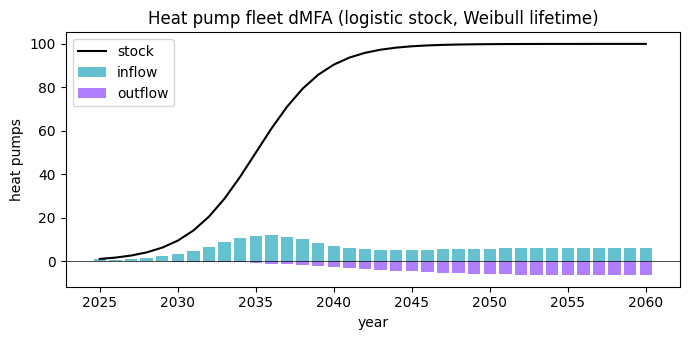

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(years, stock.values, label="stock", color="black")
ax.bar(years, inflow_values, label="inflow", color="#3fb1c5", alpha=0.8)
ax.bar(years, -outflow_values, label="outflow", color="#9c5ffd", alpha=0.8)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("year")
ax.set_ylabel("heat pumps")
ax.legend()
ax.set_title("Heat pump fleet dMFA (logistic stock, Weibull lifetime)")
fig.tight_layout()

### Derive `td_install_dmfa` and `td_use_dmfa`

- `td_install_dmfa`: normalize annual inflow → install-year shape.
  Offsets in years from `YEAR_START`. Drop trailing zeros.
- `td_use_dmfa`: from `stock_by_cohort` we know how many of an installed
  cohort are still in stock `k` years after install. Assuming constant
  per-unit annual electricity draw while in stock, the fraction of a
  unit's lifetime electricity drawn at age `k` is proportional to the
  age-`k` survival probability. We compute this from the Weibull survival
  function directly so it's independent of cohort-specific noise.

In [14]:
inflow_total = inflow_values.sum()
inflow_share = inflow_values / inflow_total
nonzero = np.where(inflow_share > 1e-6)[0]
install_offsets_years = (years[nonzero] - YEAR_START).astype("int64")
install_weights = inflow_share[nonzero]
install_weights = install_weights / install_weights.sum()

td_install_dmfa = TemporalDistribution(
    date=install_offsets_years.astype("timedelta64[Y]"),
    amount=install_weights,
)

ages = np.arange(0, 41)
from scipy.stats import weibull_min
age_survival = weibull_min.sf(ages, WEIBULL_SHAPE, scale=WEIBULL_SCALE)
use_share = age_survival / age_survival.sum()
keep = np.where(use_share > 1e-4)[0]
use_offsets_years = ages[keep].astype("int64")
use_weights = use_share[keep] / use_share[keep].sum()

td_use_dmfa = TemporalDistribution(
    date=use_offsets_years.astype("timedelta64[Y]"),
    amount=use_weights,
)

print(f"dMFA total inflow over horizon: {inflow_total:.2f} heat pumps")
print(
    f"td_install_dmfa: {len(install_weights)} bins, "
    f"first {install_offsets_years[0]}y .. last {install_offsets_years[-1]}y"
)
print(
    f"td_use_dmfa:     {len(use_weights)} bins, "
    f"first {use_offsets_years[0]}y .. last {use_offsets_years[-1]}y"
)

dMFA total inflow over horizon: 220.04 heat pumps
td_install_dmfa: 36 bins, first 0y .. last 35y
td_use_dmfa:     41 bins, first 0y .. last 40y


### Plug derived RTDs into the foreground and rerun

We rewrite `td_install` and `td_use` on the existing exchanges in place,
rather than rebuilding the database from scratch. Same demand, same COP
factors. The only change is the *shapes* of the two RTDs.

In [15]:
production_edge = next(
    e for e in hp_lifecycle.production() if e.output["code"] == "heat_pump_lifecycle"
)
production_edge["temporal_distribution"] = td_install_dmfa
production_edge.save()

elec_edge["temporal_distribution"] = td_use_dmfa
elec_edge.save()

bd.Database("foreground").process()

tlca_dmfa = TimexLCA(
    demand={heat_pump: 100},
    method=("our", "method"),
    database_dates=database_dates,
)
tlca_dmfa.build_timeline(
    starting_datetime=datetime(2025, 1, 1),
    temporal_grouping="year",
)
tlca_dmfa.lci()
tlca_dmfa.static_lcia()

print(f"Part 1 (hand-picked RTDs) static score: {tlca.static_score:>14,.2f} kg CO2-eq")
print(f"Part 2 (dMFA RTDs)         static score: {tlca_dmfa.static_score:>14,.2f} kg CO2-eq")

2026-05-09 00:23:23.613 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-09 00:23:23.613 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-09 00:23:23.619 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-09 00:23:23.621 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-09 00:23:23.621 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-09 00:23:24.098 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2099-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-09 00:23:24.098 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:563 - Reference date 2100-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-09 00:23:24.115 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-09 00:23:25.748 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


Part 1 (hand-picked RTDs) static score:     256,680.00 kg CO2-eq
Part 2 (dMFA RTDs)         static score:     134,223.34 kg CO2-eq


### Year-by-year emissions from the dMFA-driven run

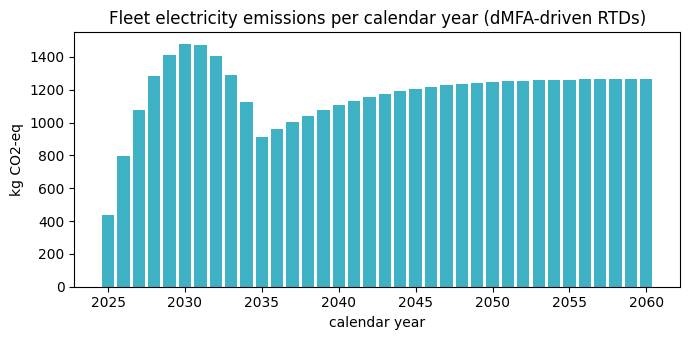

In [16]:
timeline_df = tlca_dmfa.timeline.copy()
timeline_df["draw_year"] = timeline_df["date_producer"].dt.year
elec_mask = timeline_df["producer_name"].str.contains("electricity")
elec_t = timeline_df[elec_mask].copy()

elec_t["cop_factor"] = elec_t["date_consumer"].apply(
    lambda d: get_temporal_evolution_factor(cop_factors, d)
)

def share_co2(row):
    co2_per_kwh = 0.0
    for db_name, share in row["temporal_market_shares"].items():
        if db_name == "electricity_market_2025":
            co2_per_kwh += 0.40 * share
        elif db_name == "electricity_market_2035":
            co2_per_kwh += 0.10 * share
    return float(row["amount"]) * row["cop_factor"] * co2_per_kwh

elec_t["co2_kg"] = elec_t.apply(share_co2, axis=1)

emissions_by_year = (
    elec_t.groupby("draw_year")["co2_kg"].sum().reindex(years, fill_value=0.0)
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(years, emissions_by_year.values, color="#3fb1c5")
ax.set_xlabel("calendar year")
ax.set_ylabel("kg CO2-eq")
ax.set_title("Fleet electricity emissions per calendar year (dMFA-driven RTDs)")
fig.tight_layout()

## Optional: dynamic characterization

The inventory still carries dates, so dynamic characterization works
exactly as in the original getting-started notebook.

In [17]:
from dynamic_characterization.ipcc_ar6 import characterize_co2

emission_id = bd.get_activity(("biosphere", "CO2")).id
characterization_functions = {emission_id: characterize_co2}

tlca_dmfa.dynamic_lcia(
    metric="GWP",
    time_horizon=100,
    characterization_functions=characterization_functions,
)

tlca_dmfa.dynamic_score

np.float64(134223.34499018578)

## Quick recap

1. **Demand the product**, not the process. Set total quantity for the
   horizon (`{heat_pump: 100}`).
2. **Output-side RTD** on the production edge `heat_pump_lifecycle →
   heat_pump` carries the install-year distribution (the dMFA inflow).
3. **Input-side RTDs** on consumption/biosphere edges describe the
   per-unit lifetime profile — they are evaluated relative to each
   cohort's install year via `date_consumer`.
4. `temporal_evolution_factors` with `temporal_evolution_reference=
   "consumer"` lets vintages keep their own efficiencies across all
   later draw years.
5. The fleet result falls out: matrix solve scales by demand, RTDs
   distribute scaled flows in time, background relinking picks the
   right grid mix per draw year.

Part 1 made the RTDs up; Part 2 derived them from a flodym dMFA
(`StockDrivenDSM` + `WeibullLifetime`). The notebook structure is
identical otherwise — *the bridge between dMFA and `bw_timex` is just
normalization*.